<a href="https://colab.research.google.com/github/niniqoiii/The-Visual-Storyteller/blob/main/data_and_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Project — The Visual Storyteller

**Task:** build an image captioning system that accepts an image and generates a natural-language description.

This notebook covers:
1. Data loading from the provided Google Drive ZIP file link
2. Image/text preprocessing
3. CNN feature extraction with EfficientNetB0
4. Improved caption model with stronger regularization
5. Longer training schedule with EarlyStopping and ReduceLROnPlateau
6. Saving model artifacts for `inference.ipynb`
7. Quick beam-search caption test on unseen test images



In [1]:
# Optional: install dependencies inside the notebook environment.
# Run this once if your environment is missing packages.
# %pip install -r requirements.txt

## 1. Imports and configuration

In [2]:
import os
import re
import sys
import json
import pickle
import zipfile
import shutil
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
DATA_DIR.mkdir(exist_ok=True)
ARTIFACT_DIR.mkdir(exist_ok=True)

# Google Drive FILE link for the dataset ZIP.
DRIVE_FILE_URL = "https://drive.google.com/file/d/1gwsWIb1idfEl3wDswVXcTcuzIoypTrWo/view?usp=sharing"
ZIP_PATH = DATA_DIR / "caption_data.zip"
EXTRACT_DIR = DATA_DIR / "caption_data"

# -------------------------
# Main training configuration
# -------------------------
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 64
FEATURE_BATCH_SIZE = 32
EMBED_DIM = 256
LSTM_UNITS = 256
VOCAB_SIZE = 5000
MAX_CAPTION_LENGTH_CAP = 40


EPOCHS = 30
INITIAL_LEARNING_RATE = 5e-4
DROPOUT_RATE = 0.50
EMBEDDING_DROPOUT = 0.30
LSTM_DROPOUT = 0.25
L2_REG = 1e-5

# Beam search is used only for caption generation/testing, not for training.
BEAM_WIDTH = 3

# For a quick debugging run only. Keep False for final training.
FAST_DEV_MODE = False
FAST_DEV_IMAGE_LIMIT = 1000

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))
print("Epochs:", EPOCHS)
print("Initial learning rate:", INITIAL_LEARNING_RATE)


TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Epochs: 30
Initial learning rate: 0.0005


## 2. Download and prepare the dataset

This notebook uses the **Google Drive file link** for `caption_data.zip`:

`https://drive.google.com/file/d/1gwsWIb1idfEl3wDswVXcTcuzIoypTrWo/view?usp=sharing`

The cell below will:

1. Download `caption_data.zip` from the Drive file link with `gdown.download(...)`.
2. Check that the downloaded file is a real ZIP with `zipfile.is_zipfile(...)`.
3. If Drive download fails, fall back to searching local/Colab files or asking you to upload the ZIP manually.


In [3]:
def running_in_colab() -> bool:
    return "google.colab" in sys.modules


def describe_file(path: Path) -> None:
    """Print useful information about a candidate dataset file."""
    if path.exists():
        size_mb = path.stat().st_size / (1024 * 1024)
        print(f"- {path} | {size_mb:.2f} MB | valid zip: {zipfile.is_zipfile(path)}")


def invalidate_bad_zip(path: Path) -> None:
    """Rename a bad ZIP/HTML download so the notebook does not try to extract it."""
    if path.exists() and not zipfile.is_zipfile(path):
        invalid_path = path.with_suffix(path.suffix + ".invalid")
        counter = 1
        while invalid_path.exists():
            invalid_path = path.with_suffix(path.suffix + f".invalid{counter}")
            counter += 1
        path.rename(invalid_path)
        print(f"Invalid ZIP renamed to: {invalid_path}")


def ensure_gdown_installed():
    """Import gdown, installing it automatically if needed."""
    try:
        import gdown
        return gdown
    except ImportError:
        import subprocess
        print("Installing gdown...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gdown"])
        import gdown
        return gdown


def download_zip_from_drive_file() -> Path | None:
    """Download caption_data.zip from the provided Google Drive FILE link."""
    DATA_DIR.mkdir(parents=True, exist_ok=True)

    # Remove/rename a previous broken file before downloading again.
    invalidate_bad_zip(ZIP_PATH)

    if ZIP_PATH.exists() and zipfile.is_zipfile(ZIP_PATH):
        print(f"Using existing valid ZIP: {ZIP_PATH}")
        return ZIP_PATH

    print("Downloading caption_data.zip from Google Drive file link...")
    print("Drive URL:", DRIVE_FILE_URL)

    try:
        gdown = ensure_gdown_installed()
        result = gdown.download(
            DRIVE_FILE_URL,
            str(ZIP_PATH),
            quiet=False,
            fuzzy=True,
            use_cookies=False,
        )
        print("gdown result:", result)
    except Exception as exc:
        print("Google Drive file download failed:", repr(exc))
        return None

    # gdown can sometimes save an HTML warning/error page. Verify before extraction.
    if ZIP_PATH.exists() and zipfile.is_zipfile(ZIP_PATH):
        print("Downloaded valid ZIP successfully:", ZIP_PATH)
        describe_file(ZIP_PATH)
        return ZIP_PATH

    invalidate_bad_zip(ZIP_PATH)
    print("Downloaded file was not a valid ZIP. Check that the Drive file is shared as: Anyone with the link -> Viewer.")
    return None


def find_existing_valid_zip() -> Path | None:
    """Search common Colab/project locations for a valid ZIP file."""
    search_roots = [DATA_DIR, PROJECT_DIR]
    if Path("/content").exists():
        search_roots.insert(0, Path("/content"))

    candidates = []
    seen = set()

    for root in search_roots:
        if not root.exists():
            continue
        for candidate in root.rglob("*.zip"):
            try:
                resolved = candidate.resolve()
            except Exception:
                resolved = candidate
            if resolved in seen:
                continue
            seen.add(resolved)
            candidates.append(candidate)

    if candidates:
        print("ZIP candidates found:")
        for candidate in candidates:
            describe_file(candidate)

    valid_zips = [p for p in candidates if zipfile.is_zipfile(p)]
    if not valid_zips:
        return None

    # Prefer a file named caption_data.zip; otherwise use the largest valid zip.
    named = [p for p in valid_zips if p.name.lower() == "caption_data.zip"]
    if named:
        return max(named, key=lambda p: p.stat().st_size)

    return max(valid_zips, key=lambda p: p.stat().st_size)


def upload_zip_in_colab() -> Path:
    """Open Colab upload picker and return the uploaded valid ZIP path."""
    if not running_in_colab():
        raise FileNotFoundError(
            "No valid ZIP was found. Put caption_data.zip in the data/ folder and rerun this cell."
        )

    from google.colab import files

    print("No valid dataset ZIP found from Drive or local files.")
    print("Please upload the real caption_data.zip file now.")
    uploaded = files.upload()

    if not uploaded:
        raise FileNotFoundError("No file was uploaded.")

    uploaded_paths = [Path(name) for name in uploaded.keys()]

    print("Uploaded files:")
    for path in uploaded_paths:
        describe_file(path)

    valid_uploaded = [p for p in uploaded_paths if zipfile.is_zipfile(p)]
    if not valid_uploaded:
        raise zipfile.BadZipFile(
            "The uploaded file is not a valid ZIP. Download caption_data.zip again and upload the real ZIP file."
        )

    return max(valid_uploaded, key=lambda p: p.stat().st_size)


def prepare_dataset_zip() -> Path:
    """
    Ensure there is a valid dataset ZIP at data/caption_data.zip.
    Priority order:
    1. Use existing valid data/caption_data.zip.
    2. Download from the provided Google Drive FILE link.
    3. Search local/Colab files for a valid ZIP.
    4. Ask for manual upload in Colab.
    """
    DATA_DIR.mkdir(parents=True, exist_ok=True)

    # If data/caption_data.zip exists but is broken, move it aside.
    invalidate_bad_zip(ZIP_PATH)

    if ZIP_PATH.exists() and zipfile.is_zipfile(ZIP_PATH):
        print(f"Using existing dataset ZIP: {ZIP_PATH}")
        return ZIP_PATH

    # Main path: download from the ZIP file link you provided.
    downloaded = download_zip_from_drive_file()
    if downloaded is not None and zipfile.is_zipfile(downloaded):
        return downloaded

    # Fallback: search /content, project folder, and data folder for any valid ZIP.
    candidate = find_existing_valid_zip()

    # Final fallback: ask the user to upload one in Colab.
    if candidate is None:
        candidate = upload_zip_in_colab()

    # Copy the selected valid ZIP to the expected path.
    if candidate.resolve() != ZIP_PATH.resolve():
        shutil.copy2(candidate, ZIP_PATH)
        print(f"Copied valid ZIP to expected path: {ZIP_PATH}")

    if not ZIP_PATH.exists() or not zipfile.is_zipfile(ZIP_PATH):
        raise zipfile.BadZipFile(f"Dataset file at {ZIP_PATH} is still not a valid ZIP.")

    print("Dataset ZIP ready:", ZIP_PATH)
    describe_file(ZIP_PATH)
    return ZIP_PATH


ZIP_PATH = prepare_dataset_zip()


Drive URL: https://drive.google.com/file/d/1gwsWIb1idfEl3wDswVXcTcuzIoypTrWo/view?usp=sharing


Downloading...
From (original): https://drive.google.com/uc?id=1gwsWIb1idfEl3wDswVXcTcuzIoypTrWo
From (redirected): https://drive.google.com/uc?id=1gwsWIb1idfEl3wDswVXcTcuzIoypTrWo&confirm=t&uuid=c5aaaf0c-3f71-470c-82c0-d114ec10584c
To: /content/data/caption_data.zip
100%|██████████| 1.11G/1.11G [00:09<00:00, 113MB/s]

gdown result: /content/data/caption_data.zip
Downloaded valid ZIP successfully: /content/data/caption_data.zip
- /content/data/caption_data.zip | 1061.41 MB | valid zip: True


In [4]:
# Extract dataset if needed.
# If an old/partial extraction exists but contains no images, it is removed and extracted again.

def extracted_dataset_looks_ready(path: Path) -> bool:
    if not path.exists():
        return False
    image_count = sum(1 for p in path.rglob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"})
    text_count = sum(1 for p in path.rglob("*") if p.suffix.lower() in {".txt", ".csv"})
    print(f"Existing extraction check: {image_count} images, {text_count} text/csv files")
    return image_count > 0 and text_count > 0


if extracted_dataset_looks_ready(EXTRACT_DIR):
    print("Dataset already extracted:", EXTRACT_DIR)
else:
    if EXTRACT_DIR.exists():
        print("Removing incomplete extraction:", EXTRACT_DIR)
        shutil.rmtree(EXTRACT_DIR)

    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

    print("Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(EXTRACT_DIR)

    print("Extraction completed:", EXTRACT_DIR)
    extracted_dataset_looks_ready(EXTRACT_DIR)

# Show top-level extracted files/folders
print("\nTop-level extracted files/folders:")
for p in sorted(EXTRACT_DIR.iterdir())[:20]:
    print(p.relative_to(EXTRACT_DIR))


Extracting dataset...
Extraction completed: /content/data/caption_data
Existing extraction check: 8091 images, 1 text/csv files

Top-level extracted files/folders:
Images
captions.txt


## 3. Locate images and captions

This code supports common Flickr8k-style formats, including:

- `Flickr8k.token.txt` lines like `image.jpg#0<TAB>caption`
- CSV files with columns like `image,caption`
- text files with `image.jpg caption...` rows

In [5]:
def find_image_files(root: Path):
    exts = {".jpg", ".jpeg", ".png"}
    return [p for p in root.rglob("*") if p.suffix.lower() in exts]

image_paths = find_image_files(EXTRACT_DIR)
print("Images found:", len(image_paths))
if len(image_paths) == 0:
    raise RuntimeError("No image files found. Check the dataset extraction structure.")

image_map = {p.name: str(p) for p in image_paths}

# Find likely caption files.
caption_candidates = []
for p in EXTRACT_DIR.rglob("*"):
    if p.suffix.lower() in {".txt", ".csv"}:
        name = p.name.lower()
        if any(k in name for k in ["caption", "token", "description", "result"]):
            caption_candidates.append(p)

print("Caption candidates:")
for p in caption_candidates:
    print(" -", p.relative_to(EXTRACT_DIR))

if not caption_candidates:
    raise RuntimeError("No caption file found. Please inspect the extracted dataset manually.")

Images found: 8091
Caption candidates:
 - captions.txt


In [6]:
def clean_caption(text: str) -> str:
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    # remove very short one-character tokens except meaningful digits
    tokens = [t for t in text.split() if len(t) > 1 or t.isdigit()]
    return " ".join(tokens)


def parse_caption_file(path: Path, image_names: set) -> pd.DataFrame:
    rows = []

    if path.suffix.lower() == ".csv":
        df = pd.read_csv(path)
        lower_cols = {c.lower().strip(): c for c in df.columns}
        image_col = None
        caption_col = None
        for cand in ["image", "image_name", "filename", "file", "img"]:
            if cand in lower_cols:
                image_col = lower_cols[cand]
                break
        for cand in ["caption", "comment", "description", "text"]:
            if cand in lower_cols:
                caption_col = lower_cols[cand]
                break
        if image_col and caption_col:
            for _, r in df.iterrows():
                image = str(r[image_col]).split("#")[0].strip()
                caption = clean_caption(r[caption_col])
                if image in image_names and caption:
                    rows.append((image, caption))
            return pd.DataFrame(rows, columns=["image", "caption"])

    # Plain text parser.
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            # Format: image.jpg#0<TAB>caption
            if "	" in line:
                left, right = line.split("	", 1)
                image = left.split("#")[0].strip()
                caption = right.strip()
            # Format: image.jpg,caption
            elif "," in line and line.split(",", 1)[0].strip().split("#")[0] in image_names:
                left, right = line.split(",", 1)
                image = left.split("#")[0].strip()
                caption = right.strip()
            else:
                # Fallback: find image filename inside line.
                image = None
                caption = None
                for img_name in image_names:
                    if line.startswith(img_name):
                        image = img_name
                        caption = line[len(img_name):].replace("#0", " ").strip(" ,	")
                        break
                if image is None:
                    continue

            caption = clean_caption(caption)
            if image in image_names and caption:
                rows.append((image, caption))

    return pd.DataFrame(rows, columns=["image", "caption"])

all_caption_frames = []
image_names = set(image_map.keys())
for candidate in caption_candidates:
    parsed = parse_caption_file(candidate, image_names)
    print(candidate.name, "->", len(parsed), "caption rows")
    if len(parsed) > 0:
        all_caption_frames.append(parsed)

captions_df = pd.concat(all_caption_frames, ignore_index=True).drop_duplicates()
captions_df["image_path"] = captions_df["image"].map(image_map)
captions_df = captions_df.dropna(subset=["image_path"])
captions_df["caption"] = "startseq " + captions_df["caption"] + " endseq"

print("Unique images with captions:", captions_df["image"].nunique())
print("Total captions:", len(captions_df))
captions_df.head()

captions.txt -> 40453 caption rows
Unique images with captions: 8091
Total captions: 40428


,image,caption,image_path
0,1000268201_693b08cb0e.jpg,startseq child in pink dress is climbing up se...,/content/data/caption_data/Images/1000268201_6...
1,1000268201_693b08cb0e.jpg,startseq girl going into wooden building endseq,/content/data/caption_data/Images/1000268201_6...
2,1000268201_693b08cb0e.jpg,startseq little girl climbing into wooden play...,/content/data/caption_data/Images/1000268201_6...
3,1000268201_693b08cb0e.jpg,startseq little girl climbing the stairs to he...,/content/data/caption_data/Images/1000268201_6...
4,1000268201_693b08cb0e.jpg,startseq little girl in pink dress going into ...,/content/data/caption_data/Images/1000268201_6...


Sample image: 1000268201_693b08cb0e.jpg
startseq child in pink dress is climbing up set...
   startseq girl going into wooden building endseq
startseq little girl climbing into wooden playh...
startseq little girl climbing the stairs to her...
startseq little girl in pink dress going into w...


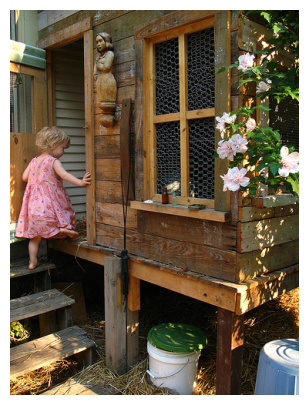

In [7]:
# Optional fast mode for debugging.
if FAST_DEV_MODE:
    selected_images = captions_df["image"].drop_duplicates().sample(
        min(FAST_DEV_IMAGE_LIMIT, captions_df["image"].nunique()), random_state=SEED
    )
    captions_df = captions_df[captions_df["image"].isin(selected_images)].reset_index(drop=True)
    print("FAST_DEV_MODE active. Images:", captions_df["image"].nunique(), "Captions:", len(captions_df))

# Show a sample image and its captions.
sample_image = captions_df["image"].iloc[0]
sample_path = captions_df.loc[captions_df["image"] == sample_image, "image_path"].iloc[0]
print("Sample image:", sample_image)
print(captions_df.loc[captions_df["image"] == sample_image, "caption"].head().to_string(index=False))

img = Image.open(sample_path)
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off");

## 4. Train/validation/test split

The split is done by **unique image**, not by caption row. This prevents captions of the same image from appearing in both train and test sets.

In [8]:
unique_images = captions_df["image"].drop_duplicates().tolist()
train_images, temp_images = train_test_split(unique_images, test_size=0.20, random_state=SEED)
val_images, test_images = train_test_split(temp_images, test_size=0.50, random_state=SEED)

train_df = captions_df[captions_df["image"].isin(train_images)].reset_index(drop=True)
val_df = captions_df[captions_df["image"].isin(val_images)].reset_index(drop=True)
test_df = captions_df[captions_df["image"].isin(test_images)].reset_index(drop=True)

print("Train images/captions:", len(train_images), len(train_df))
print("Val images/captions:", len(val_images), len(val_df))
print("Test images/captions:", len(test_images), len(test_df))

# Save test image paths for the inference notebook.
with open(ARTIFACT_DIR / "test_images.txt", "w", encoding="utf-8") as f:
    for img_name in test_images:
        f.write(image_map[img_name] + "\n")

Train images/captions: 6472 32335
Val images/captions: 809 4045
Test images/captions: 810 4048


## 5. Tokenization

Captions are converted to integer token sequences. The model learns to predict the next word from an image feature vector and a partial caption prefix.

In [9]:
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="unk")
tokenizer.fit_on_texts(train_df["caption"].tolist())

train_sequences = tokenizer.texts_to_sequences(train_df["caption"].tolist())
sequence_lengths = [len(seq) for seq in train_sequences if seq]
max_length = min(MAX_CAPTION_LENGTH_CAP, max(sequence_lengths))
vocab_size = min(VOCAB_SIZE, len(tokenizer.word_index) + 1)

print("Vocabulary size used:", vocab_size)
print("Max caption length:", max_length)
print("Top 20 words:", list(tokenizer.word_index.items())[:20])

# Save tokenizer and text config.
with open(ARTIFACT_DIR / "tokenizer.json", "w", encoding="utf-8") as f:
    f.write(tokenizer.to_json())

config = {
    "image_size": IMAGE_SIZE,
    "vocab_size": int(vocab_size),
    "max_length": int(max_length),
    "feature_dim": 1280,
    "start_token": "startseq",
    "end_token": "endseq",
    "feature_extractor": "EfficientNetB0_imagenet_pooling_avg",
    "epochs_requested": EPOCHS,
    "initial_learning_rate": INITIAL_LEARNING_RATE,
    "beam_width": BEAM_WIDTH,
}
with open(ARTIFACT_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

Vocabulary size used: 5000
Max caption length: 36
Top 20 words: [('unk', 1), ('startseq', 2), ('endseq', 3), ('in', 4), ('the', 5), ('on', 6), ('is', 7), ('and', 8), ('dog', 9), ('with', 10), ('man', 11), ('of', 12), ('two', 13), ('white', 14), ('black', 15), ('boy', 16), ('are', 17), ('woman', 18), ('girl', 19), ('to', 20)]


## 6. CNN feature extractor

A pretrained EfficientNetB0 reads each image and produces a compact visual feature vector. This keeps caption training faster than training a full CNN from scratch.

In [10]:
feature_extractor = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    pooling="avg",
    input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3),
)
feature_extractor.trainable = False

# Save the feature extractor so inference can run without downloading ImageNet weights again.
feature_extractor.save(ARTIFACT_DIR / "feature_extractor.keras")
feature_extractor.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [11]:
def preprocess_image_tf(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.cast(img, tf.float32)
    # EfficientNet in tf.keras includes its own preprocessing layer behavior;
    # keeping pixels in 0-255 range is acceptable for this model family.
    return img


def extract_and_cache_features(image_map, cache_path: Path):
    if cache_path.exists():
        print("Loading cached image features:", cache_path)
        with open(cache_path, "rb") as f:
            return pickle.load(f)

    print("Extracting CNN features for", len(image_map), "images...")
    names = list(image_map.keys())
    paths = [image_map[name] for name in names]

    ds = tf.data.Dataset.from_tensor_slices(paths)
    ds = ds.map(preprocess_image_tf, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(FEATURE_BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    preds = feature_extractor.predict(ds, verbose=1)
    features = {name: preds[i].astype("float32") for i, name in enumerate(names)}

    with open(cache_path, "wb") as f:
        pickle.dump(features, f)
    print("Saved feature cache:", cache_path)
    return features

needed_images = captions_df["image"].drop_duplicates().tolist()
needed_image_map = {name: image_map[name] for name in needed_images}
features = extract_and_cache_features(needed_image_map, ARTIFACT_DIR / "image_features_effnetb0.pkl")

print("Feature vector shape:", next(iter(features.values())).shape)

Extracting CNN features for 8091 images...
253/253 ━━━━━━━━━━━━━━━━━━━━ 53s 138ms/step
Saved feature cache: /content/artifacts/image_features_effnetb0.pkl
Feature vector shape: (1280,)


## 7. Caption training generator

For each caption, the generator creates samples like:

- image + `startseq` → next word
- image + `startseq a` → next word
- image + `startseq a dog` → next word

This is the standard teacher-forcing setup for caption generation.

In [12]:
class CaptionSequence(tf.keras.utils.Sequence):
    def __init__(self, df, features, tokenizer, max_length, batch_size, vocab_size, shuffle=True):
        super().__init__()
        self.df = df.reset_index(drop=True)
        self.features = features
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.batch_size = batch_size
        self.vocab_size = vocab_size
        self.shuffle = shuffle
        self.samples = []

        for _, row in self.df.iterrows():
            seq = tokenizer.texts_to_sequences([row["caption"]])[0]
            # Keep only valid token ids inside the restricted vocabulary.
            seq = [w if w < vocab_size else tokenizer.word_index.get("unk", 1) for w in seq]
            seq = seq[:max_length]
            for i in range(1, len(seq)):
                target = seq[i]
                if 0 < target < vocab_size and row["image"] in features:
                    self.samples.append((row["image"], seq[:i], target))

        self.indices = np.arange(len(self.samples))
        self.on_epoch_end()
        print(f"Created {len(self.samples):,} next-word samples from {len(self.df):,} captions")

    def __len__(self):
        return int(np.ceil(len(self.samples) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch = [self.samples[i] for i in batch_indices]

        X_img = np.array([self.features[img_name] for img_name, _, _ in batch], dtype="float32")
        X_seq = pad_sequences([prefix for _, prefix, _ in batch], maxlen=self.max_length, padding="pre")
        y = np.array([target for _, _, target in batch], dtype="int32")

        return {"image_features": X_img, "caption_input": X_seq}, y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

train_gen = CaptionSequence(train_df, features, tokenizer, max_length, BATCH_SIZE, vocab_size, shuffle=True)
val_gen = CaptionSequence(val_df, features, tokenizer, max_length, BATCH_SIZE, vocab_size, shuffle=False)

Created 331,754 next-word samples from 32,335 captions
Created 40,951 next-word samples from 4,045 captions


## 8. Model definition

The model combines two inputs:

1. **Image features** from EfficientNetB0
2. **Partial caption sequence** processed by an embedding layer and LSTM

Compared with the first version, this model uses:

- lower initial learning rate (`5e-4`) for more stable training;
- stronger dropout to reduce overfitting;
- L2 regularization on dense layers;
- gradient clipping in Adam;
- batch normalization after the image and text branches.

The output is a probability distribution over the next word.

In [13]:
def build_caption_model(
    feature_dim,
    vocab_size,
    max_length,
    embed_dim=256,
    lstm_units=256,
    dropout_rate=0.50,
    embedding_dropout=0.30,
    lstm_dropout=0.25,
    l2_reg=1e-5,
    learning_rate=5e-4,
):
    # Image branch: pretrained CNN features -> dense representation.
    image_input = layers.Input(shape=(feature_dim,), name="image_features")
    img = layers.Dropout(dropout_rate, name="image_dropout")(image_input)
    img = layers.Dense(
        embed_dim,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(l2_reg),
        name="image_dense",
    )(img)
    img = layers.BatchNormalization(name="image_batch_norm")(img)

    # Text branch: partial caption prefix -> LSTM representation.
    caption_input = layers.Input(shape=(max_length,), name="caption_input")
    txt = layers.Embedding(
        input_dim=vocab_size,
        output_dim=embed_dim,
        mask_zero=False,
        name="word_embedding",
    )(caption_input)
    txt = layers.SpatialDropout1D(embedding_dropout, name="embedding_spatial_dropout")(txt)
    txt = layers.LSTM(
        lstm_units,
        dropout=lstm_dropout,
        recurrent_dropout=0.0,
        name="caption_lstm",
    )(txt)
    txt = layers.BatchNormalization(name="text_batch_norm")(txt)

    # Multimodal fusion.
    merged = layers.Add(name="image_text_add")([img, txt])
    merged = layers.Dense(
        lstm_units,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(l2_reg),
        name="fusion_dense",
    )(merged)
    merged = layers.Dropout(dropout_rate, name="fusion_dropout")(merged)
    output = layers.Dense(vocab_size, activation="softmax", name="next_word")(merged)

    model = Model(
        inputs=[image_input, caption_input],
        outputs=output,
        name="visual_storyteller_caption_model_improved",
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

model = build_caption_model(
    feature_dim=config["feature_dim"],
    vocab_size=vocab_size,
    max_length=max_length,
    embed_dim=EMBED_DIM,
    lstm_units=LSTM_UNITS,
    dropout_rate=DROPOUT_RATE,
    embedding_dropout=EMBEDDING_DROPOUT,
    lstm_dropout=LSTM_DROPOUT,
    l2_reg=L2_REG,
    learning_rate=INITIAL_LEARNING_RATE,
)
model.summary()


Model: "visual_storyteller_caption_model_improved"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ caption_input       │ (None, 36)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_features      │ (None, 1280)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 36, 256)   │  1,280,000 │ caption_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_dropout       │ (None, 1280)      │          0 │ image_features[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_spatial_… │ (None, 36, 256)   │          0 │ word_embedding[0… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_dense (Dense) │ (None, 256)       │    327,936 │ image_dropout[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ caption_lstm (LSTM) │ (None, 256)       │    525,312 │ embedding_spatia… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_batch_norm    │ (None, 256)       │      1,024 │ image_dense[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_batch_norm     │ (None, 256)       │      1,024 │ caption_lstm[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_text_add      │ (None, 256)       │          0 │ image_batch_norm… │
│ (Add)               │                   │            │ text_batch_norm[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense        │ (None, 256)       │     65,792 │ image_text_add[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dropout      │ (None, 256)       │          0 │ fusion_dense[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ next_word (Dense)   │ (None, 5000)      │  1,285,000 │ fusion_dropout[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,486,088 (13.30 MB)

 Trainable params: 3,485,064 (13.29 MB)

 Non-trainable params: 1,024 (4.00 KB)

## 9. Improved training

`EPOCHS` is increased to 30, but the notebook still uses EarlyStopping. This means training can continue longer if validation loss improves, but it will stop automatically if the model starts overfitting.

The best model is saved to `artifacts/caption_model_best.keras`. The final model and the training history are also saved.

In [14]:
callbacks = [
    ModelCheckpoint(
        ARTIFACT_DIR / "caption_model_best.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=7,
        min_delta=1e-3,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_delta=1e-3,
        cooldown=1,
        min_lr=1e-6,
        verbose=1,
    ),
    CSVLogger(ARTIFACT_DIR / "training_log.csv", append=False),
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
)

model.save(ARTIFACT_DIR / "caption_model_final.keras")

history_dict = {k: [float(x) for x in v] for k, v in history.history.items()}
with open(ARTIFACT_DIR / "training_history.json", "w", encoding="utf-8") as f:
    json.dump(history_dict, f, indent=2)

best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
best_val_loss = float(np.min(history.history["val_loss"]))
training_summary = {
    "epochs_requested": EPOCHS,
    "epochs_completed": len(history.history["loss"]),
    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
    "initial_learning_rate": INITIAL_LEARNING_RATE,
    "dropout_rate": DROPOUT_RATE,
    "embedding_dropout": EMBEDDING_DROPOUT,
    "lstm_dropout": LSTM_DROPOUT,
    "l2_reg": L2_REG,
}
with open(ARTIFACT_DIR / "training_summary.json", "w", encoding="utf-8") as f:
    json.dump(training_summary, f, indent=2)

print("Best epoch:", best_epoch)
print("Best validation loss:", round(best_val_loss, 4))
print("Saved training summary to:", ARTIFACT_DIR / "training_summary.json")


Epoch 1/30
5181/5184 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1975 - loss: 5.0792
Epoch 1: val_loss improved from None to 4.07253, saving model to /content/artifacts/caption_model_best.keras

Epoch 1: finished saving model to /content/artifacts/caption_model_best.keras
5184/5184 ━━━━━━━━━━━━━━━━━━━━ 94s 16ms/step - accuracy: 0.2337 - loss: 4.6514 - val_accuracy: 0.2765 - val_loss: 4.0725 - learning_rate: 5.0000e-04
Epoch 2/30
5183/5184 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2724 - loss: 4.1091
Epoch 2: val_loss improved from 4.07253 to 3.85077, saving model to /content/artifacts/caption_model_best.keras

Epoch 2: finished saving model to /content/artifacts/caption_model_best.keras
5184/5184 ━━━━━━━━━━━━━━━━━━━━ 86s 17ms/step - accuracy: 0.2749 - loss: 4.0689 - val_accuracy: 0.2974 - val_loss: 3.8508 - learning_rate: 5.0000e-04
Epoch 3/30
5183/5184 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2826 - loss: 3.8845
Epoch 3: val_loss did not improve from 3.85077
5184/5184

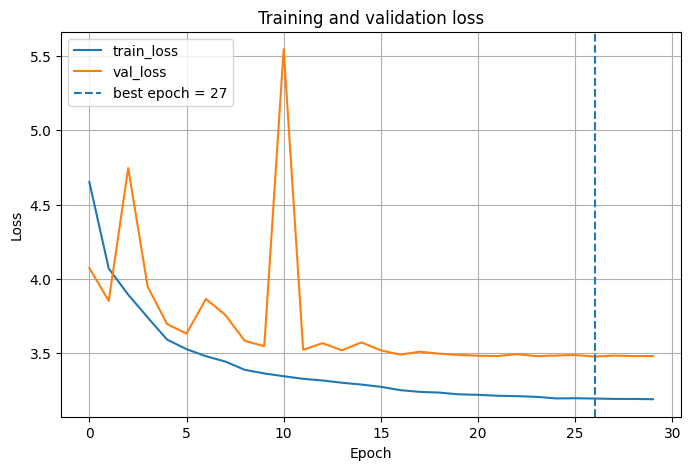

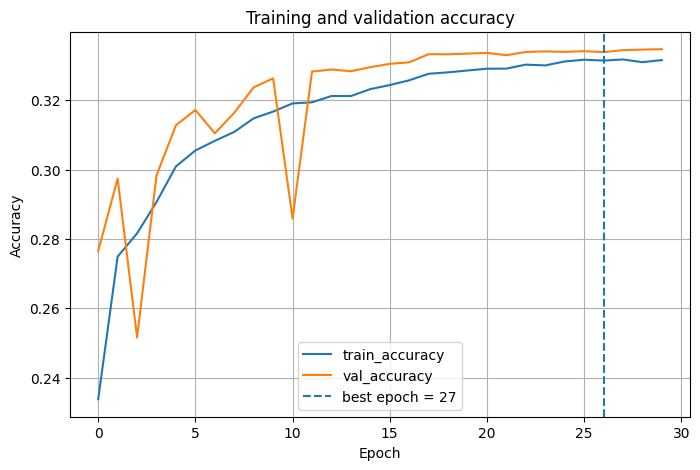

Best epoch by validation loss: 27
Best validation loss: 3.4764
Final training loss: 3.1888
Final validation loss: 3.4795


In [15]:
# Plot learning curves and mark the best validation-loss epoch.
hist = pd.DataFrame(history.history)
best_epoch_idx = int(hist["val_loss"].idxmin())
best_epoch_number = best_epoch_idx + 1

plt.figure(figsize=(8, 5))
plt.plot(hist["loss"], label="train_loss")
plt.plot(hist["val_loss"], label="val_loss")
plt.axvline(best_epoch_idx, linestyle="--", label=f"best epoch = {best_epoch_number}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(True)
plt.show()

if "accuracy" in hist:
    plt.figure(figsize=(8, 5))
    plt.plot(hist["accuracy"], label="train_accuracy")
    plt.plot(hist["val_accuracy"], label="val_accuracy")
    plt.axvline(best_epoch_idx, linestyle="--", label=f"best epoch = {best_epoch_number}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training and validation accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

print("Best epoch by validation loss:", best_epoch_number)
print("Best validation loss:", round(float(hist.loc[best_epoch_idx, "val_loss"]), 4))
print("Final training loss:", round(float(hist["loss"].iloc[-1]), 4))
print("Final validation loss:", round(float(hist["val_loss"].iloc[-1]), 4))


## 10. Quick caption-generation test with beam search

Greedy decoding chooses the single most probable next word at every step. Beam search usually gives better captions because it compares several candidate sentences and chooses the best overall sequence.

This notebook uses `BEAM_WIDTH = 3` for a better balance between quality and speed.

In [16]:
index_word = {idx: word for word, idx in tokenizer.word_index.items() if idx < vocab_size}


def clean_generated_tokens(words):
    cleaned = []
    for w in words:
        if w in {"startseq", "endseq", "unk"}:
            continue
        cleaned.append(w)
    return " ".join(cleaned).strip()


def generate_caption_from_feature_greedy(feature_vector, model, tokenizer, max_length):
    caption = "startseq"
    for _ in range(max_length):
        seq = tokenizer.texts_to_sequences([caption])[0]
        seq = pad_sequences([seq], maxlen=max_length, padding="pre")
        yhat = model.predict(
            {"image_features": feature_vector.reshape(1, -1), "caption_input": seq},
            verbose=0,
        )
        next_id = int(np.argmax(yhat[0]))
        next_word = index_word.get(next_id)
        if next_word is None or next_word == "endseq":
            break
        caption += " " + next_word
    return caption.replace("startseq", "").replace("endseq", "").strip()


def generate_caption_from_feature_beam(feature_vector, model, tokenizer, max_length, beam_width=3):
    sequences = [(["startseq"], 0.0)]

    for _ in range(max_length):
        candidates = []

        for words, score in sequences:
            if words[-1] == "endseq":
                candidates.append((words, score))
                continue

            caption = " ".join(words)
            seq = tokenizer.texts_to_sequences([caption])[0]
            seq = pad_sequences([seq], maxlen=max_length, padding="pre")
            yhat = model.predict(
                {"image_features": feature_vector.reshape(1, -1), "caption_input": seq},
                verbose=0,
            )[0]

            top_ids = np.argsort(yhat)[-beam_width:][::-1]
            for idx in top_ids:
                word = index_word.get(int(idx))
                if word is None or word == "startseq" or word == "unk":
                    continue
                prob = float(yhat[idx])
                candidates.append((words + [word], score + np.log(prob + 1e-9)))

        if not candidates:
            break

        # Length-normalized score prevents the beam from always preferring very short captions.
        sequences = sorted(
            candidates,
            key=lambda item: item[1] / max(1, len(item[0])),
            reverse=True,
        )[:beam_width]

        if all(words[-1] == "endseq" for words, _ in sequences):
            break

    best_words = sequences[0][0]
    return clean_generated_tokens(best_words)


for img_name in random.sample(test_images, min(5, len(test_images))):
    greedy_pred = generate_caption_from_feature_greedy(features[img_name], model, tokenizer, max_length)
    beam_pred = generate_caption_from_feature_beam(features[img_name], model, tokenizer, max_length, beam_width=BEAM_WIDTH)
    refs = test_df.loc[test_df["image"] == img_name, "caption"].head(3).tolist()
    print("IMAGE:", img_name)
    print("GREEDY:", greedy_pred)
    print("BEAM:", beam_pred)
    print("REFS:")
    for r in refs:
        print(" -", r.replace("startseq", "").replace("endseq", "").strip())
    print("-" * 80)


IMAGE: 2278110011_ba846e7795.jpg
GREEDY: little boy in blue shirt is running through the grass
BEAM: little boy in blue shirt is running through the grass
REFS:
 - boy in an orange short plays in bubbles
 - boy in jeans and an orange shirt chases bubbles in the air
 - child blows bubbles outside
--------------------------------------------------------------------------------
IMAGE: 1248940539_46d33ed487.jpg
GREEDY: young girl in pink shirt is standing on the beach
BEAM: little girl in pink shirt is standing on the beach
REFS:
 - three children are playing in sand near to the beach
 - three children playing in sand at beach
 - three girls play in the sand
--------------------------------------------------------------------------------
IMAGE: 2428751994_88a6808246.jpg
GREEDY: dog is running through the grass
BEAM: black and white dog is running through the grass
REFS:
 - black and white dog runs over the green grass
 - brown and white dog is running on the grass
 - dog running on the gra

In [18]:
!zip -r visual_storyteller_artifacts.zip /content/artifacts

from google.colab import files
files.download("visual_storyteller_artifacts.zip")

  adding: content/artifacts/ (stored 0%)
  adding: content/artifacts/test_images.txt (deflated 77%)
  adding: content/artifacts/training_summary.json (deflated 41%)
  adding: content/artifacts/feature_extractor.keras (deflated 12%)
  adding: content/artifacts/config.json (deflated 36%)
  adding: content/artifacts/caption_model_final.keras (deflated 7%)
  adding: content/artifacts/caption_model_best.keras (deflated 7%)
  adding: content/artifacts/image_features_effnetb0.pkl (deflated 8%)
  adding: content/artifacts/training_log.csv (deflated 57%)
  adding: content/artifacts/training_history.json (deflated 65%)
  adding: content/artifacts/tokenizer.json (deflated 69%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11. Saved artifacts

The notebook saves these files to the `artifacts/` folder:

- `caption_model_best.keras`
- `caption_model_final.keras`
- `feature_extractor.keras`
- `tokenizer.json`
- `config.json`
- `training_history.json`
- `training_log.csv`
- `training_summary.json`
- `test_images.txt`
- `image_features_effnetb0.pkl`

